In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv('train_model.csv')


In [3]:
train_cluster1 = train[train['Cluster'] == 3]
train_cluster1 = train_cluster1.fillna(0)
train_cluster1["Log_sales"] = np.log(1+train_cluster1["Sales"])

In [4]:
# Apply square root transformation to the "Sales" column
train_cluster1['Sqrt_sales'] = np.sqrt(train_cluster1['Sales'])
train_cluster1=train_cluster1.fillna(0)
train_cluster1["Log_dist"] = np.log(1+train_cluster1["CompetitionDistanceKM"])

In [5]:
train_cluster1['Promo'].unique()

array([0, 1], dtype=int64)

In [6]:
# Assuming your DataFrame is named 'df' and contains columns 'Year', 'Month', and 'Day'
train_cluster1['Date'] = pd.to_datetime(train_cluster1['Date'])
# Set the 'Date' column as the index
train_cluster1.set_index('Date', inplace=True)


In [8]:
train_cluster1['Cluster']

Date
2013-01-01    3
2013-01-01    3
2013-01-01    3
2013-01-01    3
2013-01-01    3
             ..
2015-07-31    3
2015-07-31    3
2015-07-31    3
2015-07-31    3
2015-07-31    3
Name: Cluster, Length: 134924, dtype: int64

In [9]:
train_cluster1 = train_cluster1.drop(columns = ['Unnamed: 0'])

C:\Users\PC\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


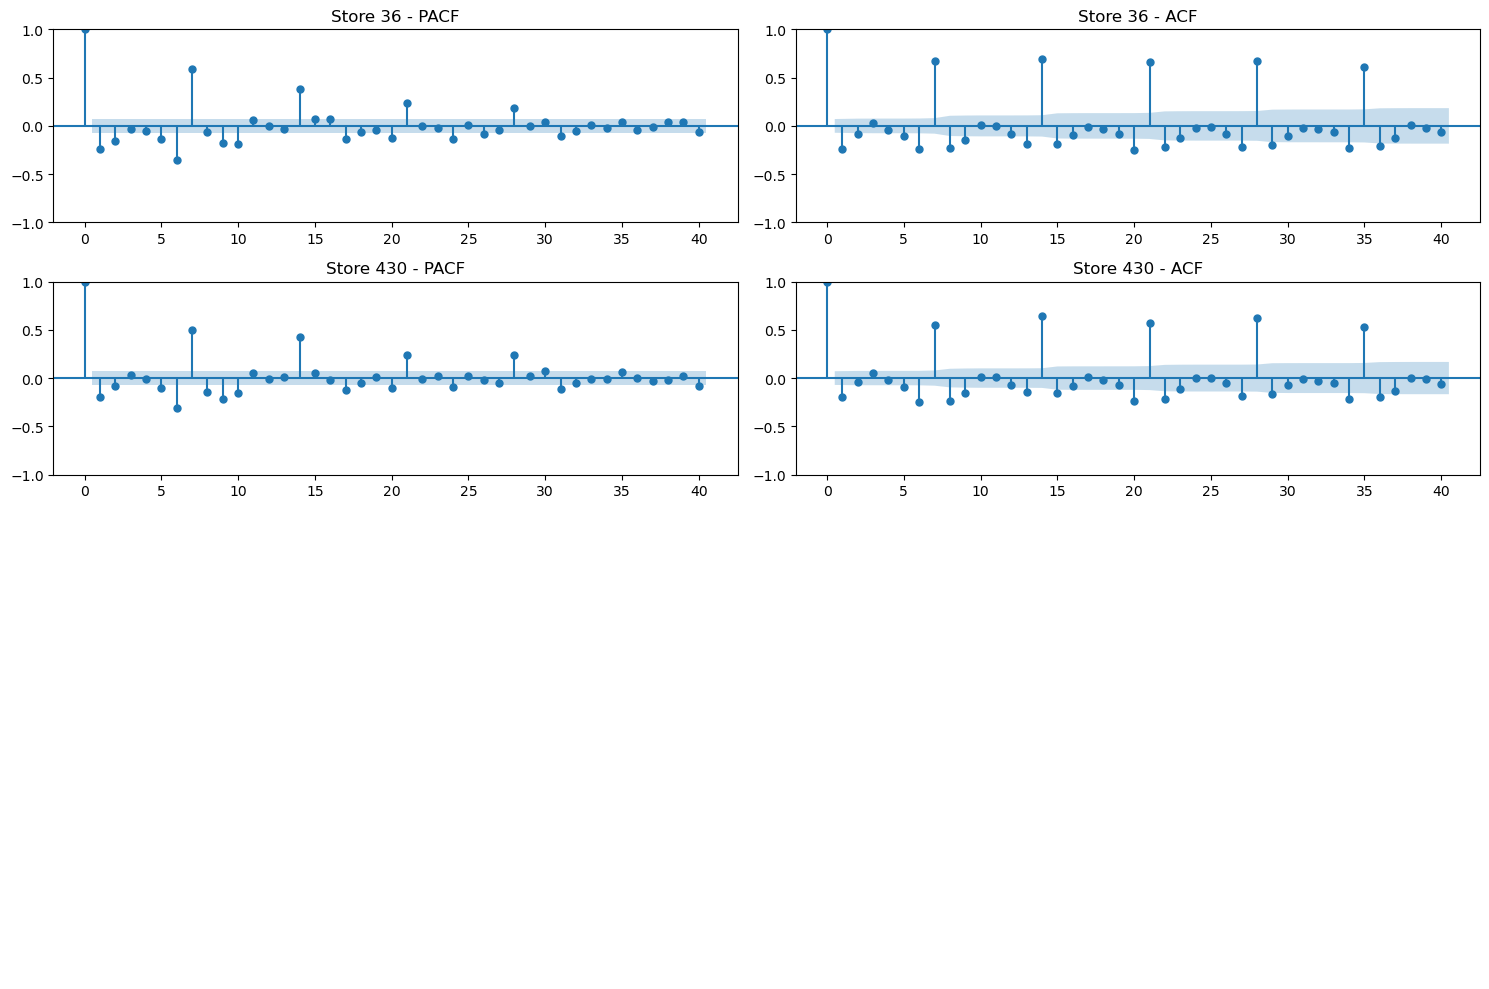

In [10]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster1['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster1[train_cluster1['Store'] == random_stores[0]]['Sales']
sales_store2 = train_cluster1[train_cluster1['Store'] == random_stores[1]]['Sales']

# Step 3: Plot PACF and ACF for each store
fig, axes = plt.subplots(4, 2, figsize=(15, 10))

# PACF for store 1
sm.graphics.tsa.plot_pacf(sales_store1, lags=40, ax=axes[0, 0])
axes[0, 0].set_title(f'Store {random_stores[0]} - PACF')

# ACF for store 1
sm.graphics.tsa.plot_acf(sales_store1, lags=40, ax=axes[0, 1])
axes[0, 1].set_title(f'Store {random_stores[0]} - ACF')

# PACF for store 2
sm.graphics.tsa.plot_pacf(sales_store2, lags=40, ax=axes[1, 0])
axes[1, 0].set_title(f'Store {random_stores[1]} - PACF')

# ACF for store 2
sm.graphics.tsa.plot_acf(sales_store2, lags=40, ax=axes[1, 1])
axes[1, 1].set_title(f'Store {random_stores[1]} - ACF')

# Hide remaining subplots
for ax in axes[2:].flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#Sales are correlated with sales from 1 week ago

C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Step 1: Select 2 random stores
random_stores = np.random.choice(train_cluster0['Store'].unique(), size=2, replace=False)

# Step 2: Extract sales data for the random stores
sales_store1 = train_cluster0[train_cluster0['Store'] == random_stores[0]]['Log_sales']
sales_store2 = train_cluster0[train_cluster0['Store'] == random_stores[1]]['Log_sales']

# Step 3: Decompose sales data
decomposition_store1 = seasonal_decompose(sales_store1, model='additive', period=365)  # Assuming yearly seasonality
decomposition_store2 = seasonal_decompose(sales_store2, model='additive', period=365)

# Step 4: Run ADF test for residual component
adf_result_store1 = adfuller(decomposition_store1.resid.dropna())
adf_result_store2 = adfuller(decomposition_store2.resid.dropna())

# Print ADF test results
print(f'ADF test results for Store {random_stores[0]} - p-value: {adf_result_store1[1]}')
print(f'ADF test results for Store {random_stores[1]} - p-value: {adf_result_store2[1]}')

NameError: name 'train_cluster0' is not defined

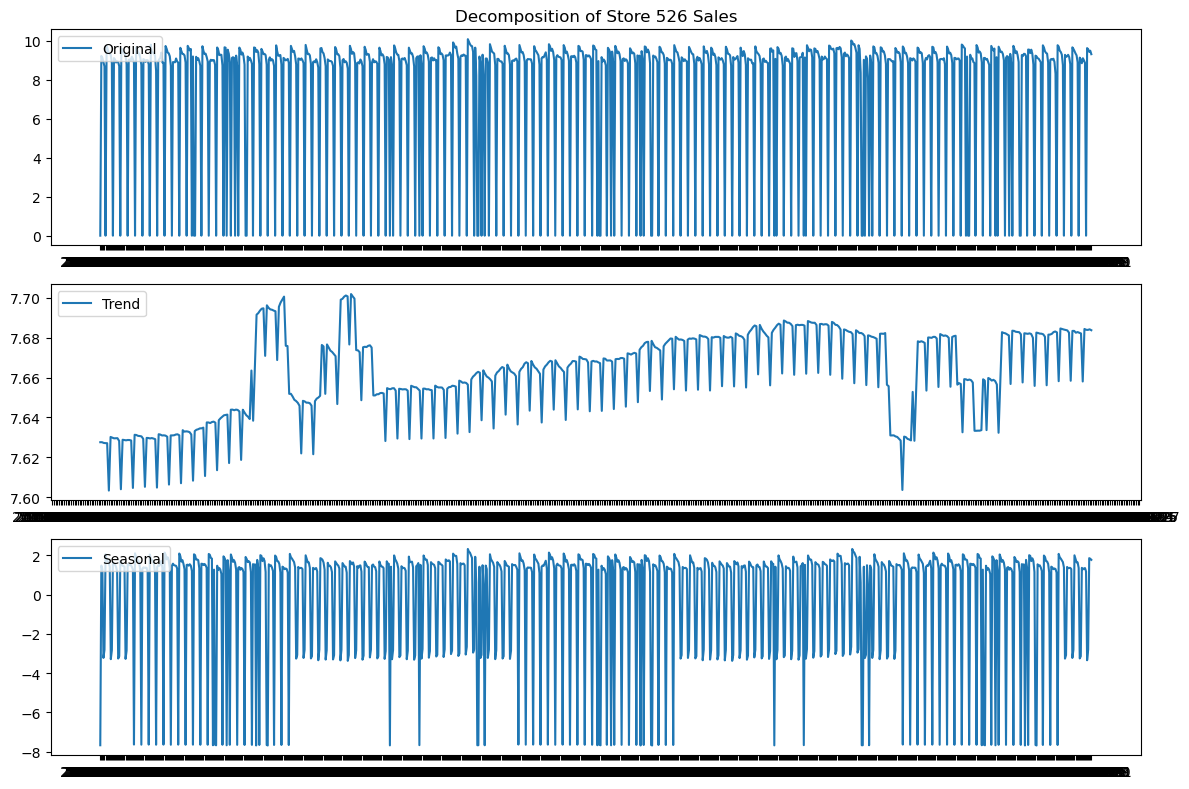

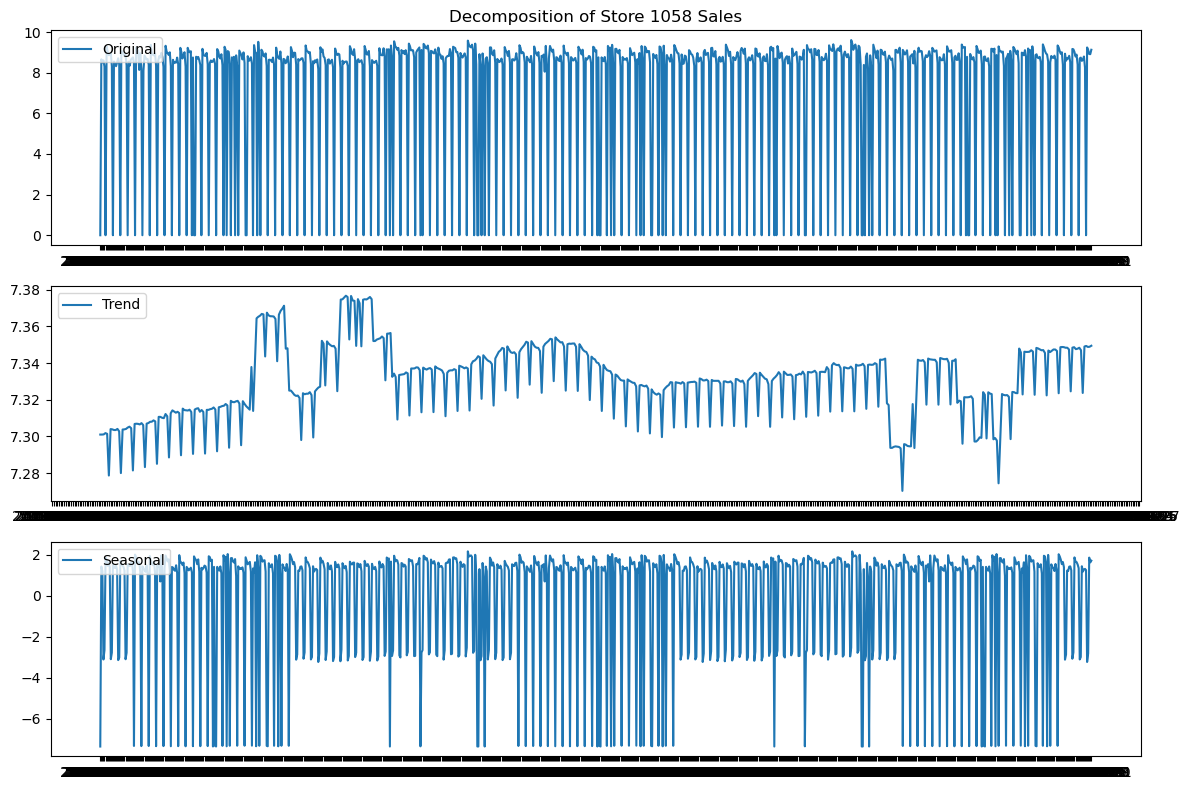

In [148]:
import matplotlib.pyplot as plt

# Plot decomposition for store 1
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store1, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[0]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store1.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store1.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Plot decomposition for store 2
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(sales_store2, label='Original')
plt.legend(loc='upper left')
plt.title(f'Decomposition of Store {random_stores[1]} Sales')
plt.subplot(3, 1, 2)
plt.plot(decomposition_store2.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(3, 1, 3)
plt.plot(decomposition_store2.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
#Stationary

In [12]:
#Add lagged sales
# Define the lagged sales intervals (every 7 days)
lag_intervals = [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]  # Add more intervals as needed

# Iterate over unique store IDs
for store_id in train_cluster1['Store'].unique():
    # Filter data for the current product and store
    condition = (train_cluster1['Store'] == store_id)
    subset = train_cluster1.loc[condition].copy()
        
    # Skip empty subsets
    if subset.empty:
        continue

    # Set lagged features to be the past 14 values
    for lag_interval in lag_intervals:
        subset[f'sales_lag_{lag_interval}'] = subset['Sales'].shift(lag_interval)

    # Drop rows with NaN values resulting from lagged shifting
    subset = subset.dropna()

    # Update the original DataFrame with the lagged features
    train_cluster1.loc[condition, subset.columns] = subset

# Drop NaN value resulting from the lagged variable
train_cluster1 = train_cluster1.dropna()
train_cluster1


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionDistanceKM,DistanceCategory,...,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,,,,,,
2013-03-12,13.0,2.0,2884.0,289.0,1.0,0.0,0.0,310.0,0.31,Close,...,6000.0,2734.0,6057.0,2390.0,5729.0,2928.0,6592.0,3375.0,6700.0,0.0
2013-03-12,20.0,2.0,6773.0,831.0,1.0,0.0,0.0,2340.0,2.34,Close,...,8396.0,5384.0,8347.0,4262.0,8558.0,4661.0,8085.0,6474.0,9065.0,0.0
2013-03-12,22.0,2.0,3133.0,435.0,1.0,0.0,0.0,1040.0,1.04,Close,...,5408.0,3325.0,4661.0,2488.0,6036.0,3099.0,5113.0,3125.0,5779.0,0.0
2013-03-12,32.0,2.0,3068.0,416.0,1.0,0.0,0.0,2910.0,2.91,Close,...,5271.0,2660.0,4858.0,1550.0,4580.0,2767.0,5678.0,3454.0,5410.0,0.0
2013-03-12,36.0,2.0,7769.0,1028.0,1.0,0.0,0.0,540.0,0.54,Close,...,10102.0,6675.0,9467.0,6721.0,9364.0,7195.0,9486.0,7832.0,8902.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,1094.0,5.0,5826.0,425.0,1.0,1.0,0.0,2380.0,2.38,Close,...,4121.0,3633.0,4570.0,5366.0,3753.0,5494.0,3882.0,6273.0,4398.0,5263.0
2015-07-31,1102.0,5.0,7211.0,704.0,1.0,1.0,0.0,850.0,0.85,Close,...,6215.0,6218.0,6093.0,8368.0,6058.0,7662.0,5804.0,8139.0,6226.0,8219.0
2015-07-31,1104.0,5.0,6878.0,472.0,1.0,1.0,0.0,260.0,0.26,Close,...,4805.0,5641.0,5411.0,6454.0,4880.0,6463.0,4298.0,6822.0,5234.0,6139.0


In [13]:
cont_features = train_cluster1.iloc[:,[22,37,38,39,40,41,42,43,44,45,46,47]]
cont_features

,DaysSinceCoupon,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,
2013-03-12,39.0,0.270027,6000.0,2734.0,6057.0,2390.0,5729.0,2928.0,6592.0,3375.0,6700.0,0.0
2013-03-12,0.0,1.205971,8396.0,5384.0,8347.0,4262.0,8558.0,4661.0,8085.0,6474.0,9065.0,0.0
2013-03-12,70.0,0.712950,5408.0,3325.0,4661.0,2488.0,6036.0,3099.0,5113.0,3125.0,5779.0,0.0
2013-03-12,39.0,1.363537,5271.0,2660.0,4858.0,1550.0,4580.0,2767.0,5678.0,3454.0,5410.0,0.0
2013-03-12,0.0,0.431782,10102.0,6675.0,9467.0,6721.0,9364.0,7195.0,9486.0,7832.0,8902.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,30.0,1.217876,4121.0,3633.0,4570.0,5366.0,3753.0,5494.0,3882.0,6273.0,4398.0,5263.0
2015-07-31,30.0,0.615186,6215.0,6218.0,6093.0,8368.0,6058.0,7662.0,5804.0,8139.0,6226.0,8219.0
2015-07-31,30.0,0.231112,4805.0,5641.0,5411.0,6454.0,4880.0,6463.0,4298.0,6822.0,5234.0,6139.0


In [14]:
train_cluster1.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'SchoolHoliday', 'CompetitionDistance', 'CompetitionDistanceKM',
       'DistanceCategory', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'CompetitionOpenSinceYear.1',
       'WeeksSinceLastCompOpen', 'MonthsSinceLastCompOpen',
       'YearsSinceLastCompOpen', 'Promo2', 'PromoInterval',
       'WeeksSinceLastPromo', 'MonthsSinceLastPromo', 'YearsSinceLastPromo',
       'LastCouponSend', 'DaysSinceCoupon', 'Cluster', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'Log_sales', 'Sqrt_sales',
       'Log_dist', 'sales_lag_7', 'sales_lag_14', 'sales_lag_21',
       'sales_lag_28', 'sales_lag_35', 'sales_lag_42', 'sales_lag_49',
       'sales_lag_56', 'sales_lag_63', 'sales_lag_70'],
      dtype='object')

In [15]:
cat_features = train_cluster1.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34]]
cat_features

,DayOfWeek,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
Date,,,,,,,,,,,,,,,,
2013-03-12,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2013-03-12,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,5.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2015-07-31,5.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [16]:
features = train_cluster1.iloc[:,[1,4,5,6,16,24,25,26,27,28,29,30,31,32,33,34,22,37,38,39,40,41,42,43,44,45,46,47]]

0

In [17]:
#Find relationship between sales and special offer
import statsmodels.api as sm
# Add a constant term to the independent variables
X = sm.add_constant(features)

# Define dependent variable
y = train_cluster1['Sqrt_sales']

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())
#p-value is low, which means there is significant relationship between sales and special offer

                            OLS Regression Results                            
Dep. Variable:             Sqrt_sales   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                 9.278e+04
Date:                Thu, 09 May 2024   Prob (F-statistic):               0.00
Time:                        21:19:12   Log-Likelihood:            -4.2271e+05
No. Observations:              122464   AIC:                         8.455e+05
Df Residuals:                  122439   BIC:                         8.457e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -16.0320      0.104   -1

In [19]:
features = features.drop(columns = "DaysSinceCoupon")

In [49]:
corrmatrix = train_cluster1.iloc[:,[3,13,18,22,36,37,38,39,40,41,42,43,44,45,46,47]]
corrmatrix

,Customers,WeeksSinceLastCompOpen,WeeksSinceLastPromo,DaysSinceCoupon,Sqrt_sales,Log_dist,sales_lag_7,sales_lag_14,sales_lag_21,sales_lag_28,sales_lag_35,sales_lag_42,sales_lag_49,sales_lag_56,sales_lag_63,sales_lag_70
Date,,,,,,,,,,,,,,,,
2013-03-12,289.0,,175,39.0,53.702886,0.270027,6000.0,2734.0,6057.0,2390.0,5729.0,2928.0,6592.0,3375.0,6700.0,0.0
2013-03-12,831.0,202,,0.0,82.298238,1.205971,8396.0,5384.0,8347.0,4262.0,8558.0,4661.0,8085.0,6474.0,9065.0,0.0
2013-03-12,435.0,,42,70.0,55.973208,0.712950,5408.0,3325.0,4661.0,2488.0,6036.0,3099.0,5113.0,3125.0,5779.0,0.0
2013-03-12,416.0,,175,39.0,55.389530,1.363537,5271.0,2660.0,4858.0,1550.0,4580.0,2767.0,5678.0,3454.0,5410.0,0.0
2013-03-12,1028.0,510,,0.0,88.141931,0.431782,10102.0,6675.0,9467.0,6721.0,9364.0,7195.0,9486.0,7832.0,8902.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-31,425.0,126,44,30.0,76.328239,1.217876,4121.0,3633.0,4570.0,5366.0,3753.0,5494.0,3882.0,6273.0,4398.0,5263.0
2015-07-31,704.0,143,44,30.0,84.917607,0.615186,6215.0,6218.0,6093.0,8368.0,6058.0,7662.0,5804.0,8139.0,6226.0,8219.0
2015-07-31,472.0,182,227,30.0,82.933708,0.231112,4805.0,5641.0,5411.0,6454.0,4880.0,6463.0,4298.0,6822.0,5234.0,6139.0


C:\Users\PC\AppData\Local\Temp\ipykernel_56072\3551483737.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = corrmatrix.corr(method='pearson')


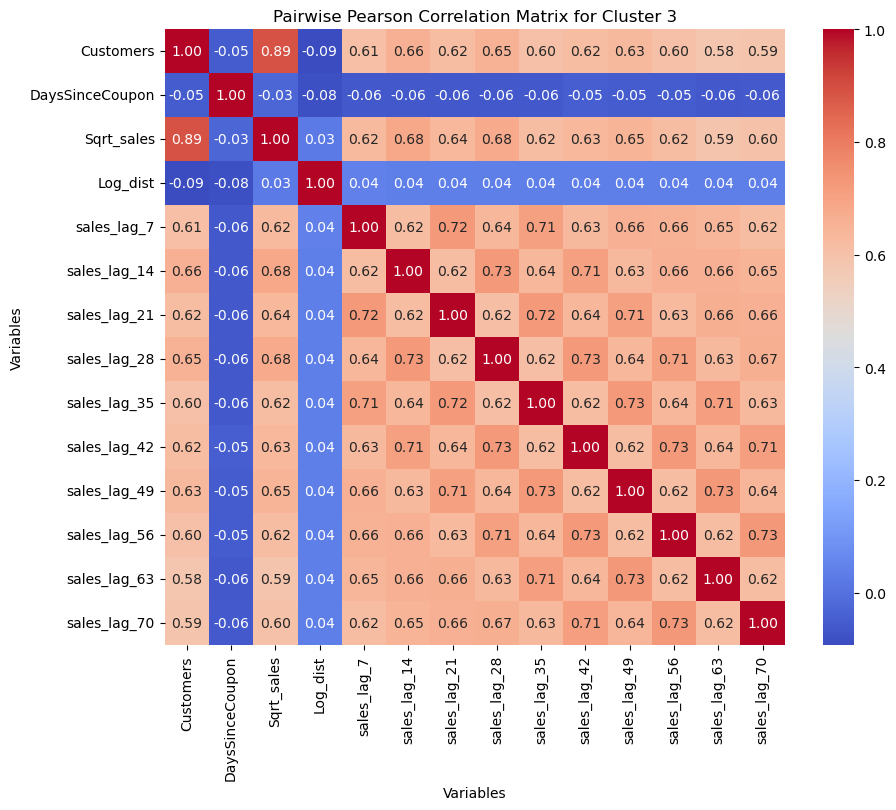

In [50]:
import pandas as pd
import seaborn as sns

# Assuming your DataFrame is named 'df' and contains the variables for which you want to compute correlations

# Compute pairwise Pearson correlation matrix
correlation_matrix = corrmatrix.corr(method='pearson')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pairwise Pearson Correlation Matrix for Cluster 3")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

Point Biserial test

In [51]:
from scipy.stats import pointbiserialr

# Assuming your DataFrame is named 'df' and contains the binary feature columns and the 'Sales' column

# Iterate over each binary feature column
for column in cat_features.columns:
    # Calculate Point-Biserial correlation coefficient and p-value
    correlation_coefficient, p_value = pointbiserialr(train_cluster1[column], train_cluster1['Sqrt_sales'])
    
    # Print results
    print(f"Point-Biserial Correlation for Cluster 3 {column}: {correlation_coefficient}, p-value: {p_value}")
#Remove Open and Promo

Point-Biserial Correlation for Cluster 3 DayOfWeek: -0.5038856403179892, p-value: 0.0
Point-Biserial Correlation for Cluster 3 Open: 0.9203646598949556, p-value: 0.0
Point-Biserial Correlation for Cluster 3 Promo: 0.39320520079527743, p-value: 0.0
Point-Biserial Correlation for Cluster 3 SchoolHoliday: 0.08143014316451608, p-value: 3.384355109004151e-179
Point-Biserial Correlation for Cluster 3 Promo2: -0.04932576646595981, p-value: 7.668761217385804e-67
Point-Biserial Correlation for Cluster 3 Assortment_a: -0.05491975252299097, p-value: 1.9442120440920662e-82
Point-Biserial Correlation for Cluster 3 Assortment_b: 0.020099521193174697, p-value: 2.00066593139665e-12
Point-Biserial Correlation for Cluster 3 Assortment_c: 0.05196857025274371, p-value: 5.310036065783099e-74
Point-Biserial Correlation for Cluster 3 StoreType_a: -0.022977415003846282, p-value: 8.84611130265318e-16
Point-Biserial Correlation for Cluster 3 StoreType_b: 0.020099521193174697, p-value: 2.00066593139665e-12
Point

# Cross-validation for ML models

0. Baseline model

In [ ]:
#MSE of baseline model to compare with
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Assign 'y_true' as the actual target variable and 'y_pred_mean' as the mean prediction
y_true = train_cluster1['Sqrt_sales'] 
y_pred_mean = np.full_like(y_true, y_true.mean())  # Predicting the mean for every sample

mae_base = mean_absolute_error(y_true, y_pred_mean)
print(f'MAE: {mae_base}')
# Calculate MSE for the mean prediction
mse_base = mean_squared_error(y_true, y_pred_mean)
print(f'Mean Squared Error for Mean Prediction: {mse_base}')


1. Lagged sales

In [22]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

In [23]:
#Linear Regression on logged sales
# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize linear regression model
model = LinearRegression()

X = features
y = train_cluster1['Sqrt_sales']
        
# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Display the mean of mean squared error scores
mae_linear_scaled = -np.mean(mae_scores)
print(f'MAE Scores for Linear Regression: {mae_linear_scaled}')
    
# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_linear = -np.mean(mse_scores)
# Display the mean of mean squared error scores
print(f'MSE Scores for Linear Regression with raw data: {mean_mse_linear}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_linear = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'R2 Scores for Linear Regression with raw data: {mean_r2_linear}')

MAE Scores for Linear Regression: 5.7081214860632254
MSE Scores for Linear Regression with raw data: 72.33691309978528
R2 Scores for Linear Regression with raw data: 0.9359834617036951


In [25]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

#Random Forest with raw data 

# Define the number of splits for time series cross-validation
num_splits = 5

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=num_splits)

# Initialize Random Forest Regressor model
model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

X = features
y = train_cluster1['Sqrt_sales']

# Perform time series cross-validation and get MAE scores for each split
mae_scores = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=tscv)
# Calculate and print the mean MAE score
mean_mae_RF = -np.mean(mae_scores)
# Display the mean of MSE scores
print(f'MAE Scores for RF with raw data: {mean_mae_RF}')

# Perform time series cross-validation and get MSE scores for each split
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=tscv)
# Calculate and print the mean MSE score
mean_mse_RF = -np.mean(mse_scores)
# Display the mean of MSE scores
print(f'MSE Scores for RF with raw data: {mean_mse_RF}')

# Perform time series cross-validation and get R-squared scores for each split
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=tscv)
# Calculate and print the mean R-squared score
mean_r2_RF = np.mean(r2_scores)
# Display the mean of R2 scores
print(f'Mean of R2 Scores for RF: {mean_r2_RF}')

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptro

MAE Scores for RF with raw data: 17.620955112014116


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptro

MSE Scores for RF with raw data: 438.6897885429191


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean of R2 Scores for RF: -0.7600666342488804


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


1.1. Lagged features with scaling 

2. Log_sales

# Using Linear model for prediction

3.2. Predict using linear model

In [52]:
#Use the Linear Regression model on raw data with 14 lagged sales and offer
#Set Train data
X_train = features
y_train = train_cluster1['Sqrt_sales']
        
# Initialize a model
final_model = MLPRegressor(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=100)

# Train the model on the historical data from 2016
final_model.fit(X_train, y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(10, 5), max_iter=100)

In [30]:
test = pd.read_csv('test_model.csv', parse_dates = ['Date'], dayfirst=True, low_memory = False)
test = test.drop(columns = "Unnamed: 0")
test.set_index('Date', inplace=True)

In [31]:
test_cluster = test[test['Cluster'] == 3]

In [32]:
test_cluster.columns
test_cluster = test_cluster.drop(columns = ['Sales','Customers','Competitionsincedate','WeeksSinceLastCompOpen','Promosincedate',
       'WeeksSinceLastPromo','Cluster','LastCouponSend'])
test_cluster['StateHoliday_b'] = 0
test_cluster['StateHoliday_c'] = 0
test_cluster['Log_dist'] = np.log(test_cluster['CompetitionDistance'])

C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [33]:
features.columns

Index(['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'Promo2', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'Log_dist', 'sales_lag_7',
       'sales_lag_14', 'sales_lag_21', 'sales_lag_28', 'sales_lag_35',
       'sales_lag_42', 'sales_lag_49', 'sales_lag_56', 'sales_lag_63',
       'sales_lag_70'],
      dtype='object')

In [34]:
test_features = test_cluster.drop(columns = 'CompetitionDistance')

In [36]:
train_cluster1['Store'] = train_cluster1['Store'].astype(int)

In [37]:
cluster_tomerge = train_cluster1.iloc[:,[0,1,2]]
# Filter train_df to include data from 70 days before 31/7/2015
start_date_train = pd.to_datetime('2015-05-22')  # 70 days before 31/7/2015
train_df_filtered = cluster_tomerge[cluster_tomerge.index >= start_date_train]

# Concatenate train and test datasets vertically
combined_df = pd.concat([train_df_filtered, test_features], axis=0)


In [38]:
combined_df['Date']=combined_df.index

In [39]:
combined_df = combined_df[['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'SchoolHoliday',
       'Promo2', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c','DaysSinceCoupon','Log_dist', 'Date']]

In [40]:
combined_df['DaysSinceCoupon']=combined_df['DaysSinceCoupon'].fillna(0).astype(int)

In [57]:
import random
# Extract unique store numbers from the "Store" column
unique_store_numbers = test_features['Store'].unique()

# Choose 2 random store numbers
random_store_numbers = random.sample(list(unique_store_numbers), 2)

# Now 'random_store_numbers' contains 2 randomly chosen store numbers from the "Store" column
print("Randomly chosen store numbers:", random_store_numbers)

Randomly chosen store numbers: [736, 1107]


In [58]:
test_0 = test_features.copy()

# List to store subsets with lagged features
lagged_subsets = []

for store in random_store_numbers:
    # Filter data for the current product and store
    condition = (combined_df['Store'] == store)
    subset = combined_df.loc[condition].copy()
        
    lagged_subsets.append(subset)

In [43]:
lagged_subsets

[            Store  DayOfWeek   Sales  Open  Promo  SchoolHoliday  Promo2  \
 Date                                                                       
 2015-05-22   1065        5.0  5025.0   NaN    NaN            NaN     NaN   
 2015-05-23   1065        6.0  3123.0   NaN    NaN            NaN     NaN   
 2015-05-24   1065        7.0     0.0   NaN    NaN            NaN     NaN   
 2015-05-25   1065        1.0     0.0   NaN    NaN            NaN     NaN   
 2015-05-26   1065        2.0  3815.0   NaN    NaN            NaN     NaN   
 ...           ...        ...     ...   ...    ...            ...     ...   
 2015-09-13   1065        7.0     NaN   0.0    0.0            0.0     1.0   
 2015-09-14   1065        1.0     NaN   1.0    1.0            1.0     1.0   
 2015-09-15   1065        2.0     NaN   1.0    1.0            0.0     1.0   
 2015-09-16   1065        3.0     NaN   1.0    1.0            0.0     1.0   
 2015-09-17   1065        4.0     NaN   1.0    1.0            0.0     1.0   

In [61]:
# Specify the date range for training and testing
start_date_test = pd.to_datetime('2015-08-01')
end_date_test = pd.to_datetime('2015-09-17')

predicted_sales = []

for subset in (lagged_subsets):
    # Initialize test_data once for the entire subset
    subset_test = subset.copy()

    for day in pd.date_range(start=start_date_test, end=end_date_test):
        test_data = subset_test[subset_test['Date'] <= day].copy()
        # Create lagged sales features for each week up to 10 weeks ago
        num_weeks = 10
        for i in range(1, num_weeks + 1):
            lagged_sales_col = f'sales_lag_{i * 7}'  # Create column name for lagged sales
            test_data[lagged_sales_col] = test_data['Sales'].shift(i * 7)  # Shift sales by multiples of 7 days

        # Drop rows with NaN values resulting from lagged shifting
        test_data = test_data.fillna(0)

        #Make X_test
        x = test_data.drop(['Sales','Store','DaysSinceCoupon'],axis=1)
        X_test = x[x['Date'] == day].drop('Date',axis = 1)
        
        #Initiate the predictions
        predictions = final_model.predict(X_test)

        #Update the subset
        subset_test.loc[subset['Date'] == day, 'Sales'] = predictions**2
    
    #Retain the only part from 31/07/2017 onward
    subset_test = subset_test[subset_test['Date'] >= start_date_test]
    # Replace the old subset with the updated one in lagged_subsets
    predicted_sales.append(subset_test)

In [62]:
store1065 = predicted_sales[0]
store1065.loc[store1065['Sales'] < 50, 'Sales'] = 0
store1065

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,736,6.0,3450.455175,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,31,7.408531,2015-08-01
2015-08-02,736,7.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,32,7.408531,2015-08-02
2015-08-03,736,1.0,3450.455175,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,33,7.408531,2015-08-03
2015-08-04,736,2.0,3450.455175,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,34,7.408531,2015-08-04
2015-08-05,736,3.0,3450.455175,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,35,7.408531,2015-08-05
2015-08-06,736,4.0,3450.455175,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,36,7.408531,2015-08-06
2015-08-07,736,5.0,3450.455175,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,37,7.408531,2015-08-07
2015-08-08,736,6.0,3450.455175,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,38,7.408531,2015-08-08
2015-08-09,736,7.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,39,7.408531,2015-08-09


In [55]:
store756 = predicted_sales[1]
store756.loc[store756['Sales'] < 50, 'Sales'] = 0
store756

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,Promo2,Assortment_a,Assortment_b,Assortment_c,...,StoreType_b,StoreType_c,StoreType_d,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,DaysSinceCoupon,Log_dist,Date
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-01,706,6.0,3450.455175,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,61,8.965718,2015-08-01
2015-08-02,706,7.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,62,8.965718,2015-08-02
2015-08-03,706,1.0,3450.455175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,63,8.965718,2015-08-03
2015-08-04,706,2.0,3450.455175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,64,8.965718,2015-08-04
2015-08-05,706,3.0,3450.455175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,65,8.965718,2015-08-05
2015-08-06,706,4.0,3450.455175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,66,8.965718,2015-08-06
2015-08-07,706,5.0,3450.455175,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,67,8.965718,2015-08-07
2015-08-08,706,6.0,3450.455175,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,68,8.965718,2015-08-08
2015-08-09,706,7.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,69,8.965718,2015-08-09


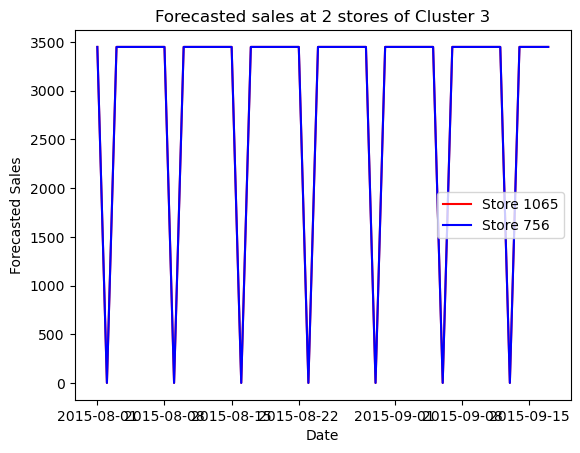

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_actual is your DataFrame containing the actual sales data
# Assuming df_forecast is your DataFrame containing the forecasted sales for the next 15 days

# Plot forecasted sales data
plt.plot(store1065['Sales'], label='Store 1065', color='red')
plt.plot(store756['Sales'], label='Store 756', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.title('Forecasted sales at 2 stores of Cluster 3')
plt.legend()
# Show plot
plt.show()

In [ ]:
test = pd.read_csv('test_model.csv', parse_dates = ['Date'], dayfirst=True, low_memory = False)
test = test.drop(columns = "Unnamed: 0")
test.set_index('Date', inplace=True)

test_cluster = test[test['Cluster'] == 2]

test_cluster.columns
test_cluster = test_cluster.drop(columns = ['Sales','Customers','Competitionsincedate','WeeksSinceLastCompOpen','Promosincedate',
       'WeeksSinceLastPromo','Cluster','LastCouponSend'])
test_cluster['StateHoliday_b'] = 0
test_cluster['StateHoliday_c'] = 0
test_cluster['Log_dist'] = np.log(test_cluster['CompetitionDistance'])



features.columns

test_features = test_cluster.drop(columns = 'CompetitionDistance')



train_cluster2['Store'] = train_cluster2['Store'].astype(int)

cluster_tomerge = train_cluster2.iloc[:,[0,1,2]]
# Filter train_df to include data from 70 days before 31/7/2015
start_date_train = pd.to_datetime('2015-05-22')  # 70 days before 31/7/2015
train_df_filtered = cluster_tomerge[cluster_tomerge.index >= start_date_train]

# Concatenate train and test datasets vertically
combined_df = pd.concat([train_df_filtered, test_features], axis=0)


combined_df['Date']=combined_df.index



combined_df = combined_df[['Store', 'DayOfWeek', 'Sales', 'Open', 'Promo', 'SchoolHoliday',
       'Promo2', 'Assortment_a', 'Assortment_b',
       'Assortment_c', 'StoreType_a', 'StoreType_b', 'StoreType_c',
       'StoreType_d', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c','DaysSinceCoupon','Log_dist', 'Date']]

combined_df['DaysSinceCoupon']=combined_df['DaysSinceCoupon'].fillna(0).astype(int)

import random
# Extract unique store numbers from the "Store" column
unique_store_numbers = test_features['Store'].unique()

# Choose 2 random store numbers
random_store_numbers = random.sample(list(unique_store_numbers), 2)

# Now 'random_store_numbers' contains 2 randomly chosen store numbers from the "Store" column
print("Randomly chosen store numbers:", random_store_numbers)

test_0 = test_features.copy()

# List to store subsets with lagged features
lagged_subsets = []

for store in random_store_numbers:
    # Filter data for the current product and store
    condition = (combined_df['Store'] == store)
    subset = combined_df.loc[condition].copy()
        
    lagged_subsets.append(subset)

lagged_subsets

# Specify the date range for training and testing
start_date_test = pd.to_datetime('2015-08-01')
end_date_test = pd.to_datetime('2015-09-17')

predicted_sales = []

for subset in (lagged_subsets):
    # Initialize test_data once for the entire subset
    subset_test = subset.copy()

    for day in pd.date_range(start=start_date_test, end=end_date_test):
        test_data = subset_test[subset_test['Date'] <= day].copy()
        # Create lagged sales features for each week up to 10 weeks ago
        num_weeks = 10
        for i in range(1, num_weeks + 1):
            lagged_sales_col = f'sales_lag_{i * 7}'  # Create column name for lagged sales
            test_data[lagged_sales_col] = test_data['Sales'].shift(i * 7)  # Shift sales by multiples of 7 days

        # Drop rows with NaN values resulting from lagged shifting
        test_data = test_data.fillna(0)

        #Make X_test
        x = test_data.drop(['Sales','Store'],axis=1)
        X_test = x[x['Date'] == day].drop('Date',axis = 1)
        
        #Initiate the predictions
        predictions = final_model.predict(X_test)

        #Update the subset
        subset_test.loc[subset['Date'] == day, 'Sales'] = predictions**2
    
    #Retain the only part from 31/07/2017 onward
    subset_test = subset_test[subset_test['Date'] >= start_date_test]
    # Replace the old subset with the updated one in lagged_subsets
    predicted_sales.append(subset_test)

store251 = predicted_sales[0]
store251.loc[store251['Sales'] < 50, 'Sales'] = 0
store251

store336 = predicted_sales[1]
store336.loc[store336['Sales'] < 50, 'Sales'] = 0
store336

import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_actual is your DataFrame containing the actual sales data
# Assuming df_forecast is your DataFrame containing the forecasted sales for the next 15 days

# Plot forecasted sales data
plt.plot(store251['Sales'], label='Store 251', color='red')
plt.plot(store336['Sales'], label='Store 336', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.title('Forecasted sales at 2 stores of Cluster 2')
plt.legend()
# Show plot
plt.show()